Student Name: Pratik Shrestha
Student ID: 2413998 
Task 2

In [24]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import os
import time
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow Version: 2.20.0
GPU: []


In [46]:
BASE_PATH = '/content/drive/MyDrive/6CS012_Vision/dataset/Scene Classification/'

TRAIN_PATH = os.path.join(BASE_PATH, 'train')
TEST_PATH  = os.path.join(BASE_PATH, 'test')
MODEL_SAVE = '/content/drive/MyDrive/6CS012_Vision/models/'
os.makedirs(MODEL_SAVE, exist_ok=True)
IMG_SIZE = (128, 128)
BATCH_SIZE = 128
NUM_CLASSES = 6
CLASS_NAMES = sorted(os.listdir(TRAIN_PATH))

print("Classes:", CLASS_NAMES)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [26]:
def clean_corrupted_images(folder):

    removed = 0
    checked = 0

    for root, dirs, files in os.walk(folder):

        for fname in files:

            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):

                fpath = os.path.join(root, fname)
                checked += 1

                try:
                    img = Image.open(fpath)
                    img.verify()

                except Exception:

                    print("Removing:", fpath)

                    os.remove(fpath)
                    removed += 1

    print(f"\nChecked: {checked}")
    print(f"Removed: {removed}")

print("Checking train folder...")
clean_corrupted_images(TRAIN_PATH)

print("\nChecking test folder...")
clean_corrupted_images(TEST_PATH)

print("\nDataset cleaned successfully.")

Checking train folder...

Checked: 13992
Removed: 0

Checking test folder...

Checked: 3000
Removed: 0

Dataset cleaned successfully.


In [27]:
print("=== DATASET STATISTICS ===")

train_counts = {}
test_counts = {}

for cls in CLASS_NAMES:

    train_counts[cls] = len(os.listdir(os.path.join(TRAIN_PATH, cls)))
    test_counts[cls]  = len(os.listdir(os.path.join(TEST_PATH, cls)))

print("\nTrain Counts:")
print(train_counts)

print("\nTest Counts:")
print(test_counts)

print("\nTotal Train Images:", sum(train_counts.values()))
print("Total Test Images:", sum(test_counts.values()))

=== DATASET STATISTICS ===

Train Counts:
{'buildings': 2184, 'forest': 2264, 'glacier': 2397, 'mountain': 2505, 'sea': 2267, 'street': 2375}

Test Counts:
{'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}

Total Train Images: 13992
Total Test Images: 3000


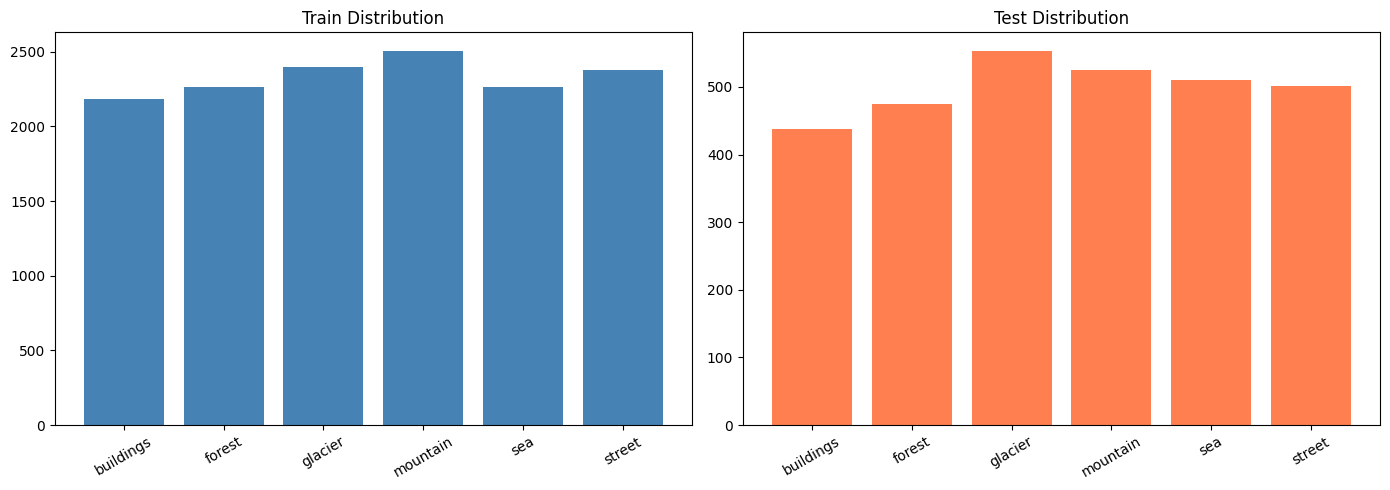

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].bar(
    train_counts.keys(),
    train_counts.values(),
    color='steelblue'
)

axes[0].set_title('Train Distribution')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(
    test_counts.keys(),
    test_counts.values(),
    color='coral'
)

axes[1].set_title('Test Distribution')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [29]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [30]:
train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

Found 11196 images belonging to 6 classes.


In [31]:
val_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 2796 images belonging to 6 classes.


In [32]:
test_gen = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTrain batches: {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")
print(f"Test batches: {len(test_gen)}")

Found 3000 images belonging to 6 classes.

Train batches: 350
Validation batches: 88
Test batches: 94


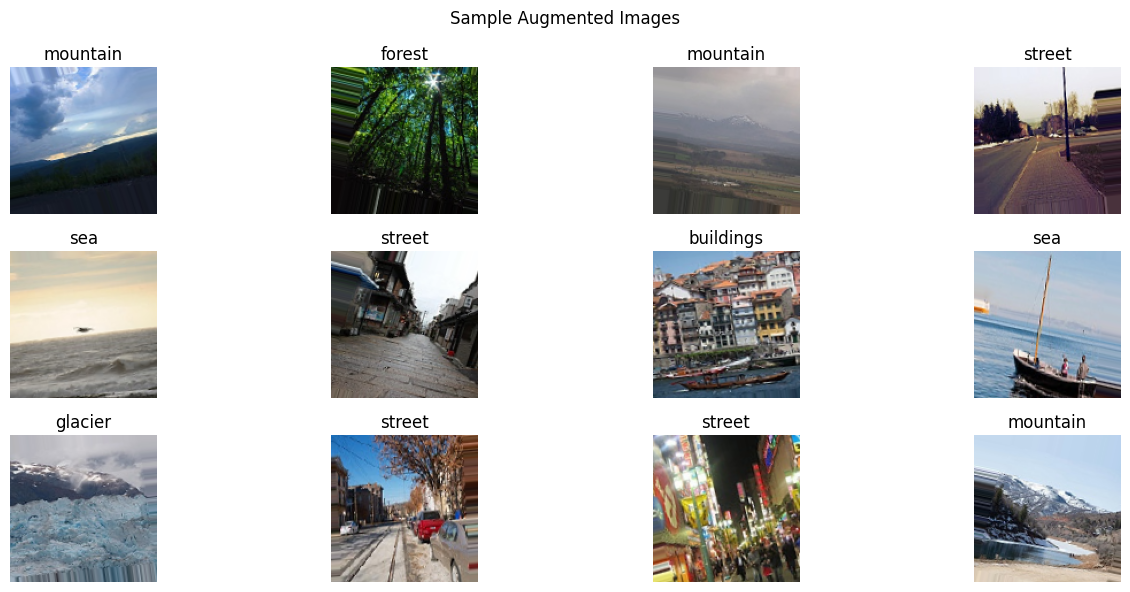

In [33]:
images, labels = next(train_gen)

plt.figure(figsize=(14,6))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(images[i])

    label = CLASS_NAMES[np.argmax(labels[i])]

    plt.title(label)

    plt.axis('off')

plt.suptitle("Sample Augmented Images")
plt.tight_layout()
plt.show()

In [35]:
def plot_history(history, title):

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')

    ax1.set_title(f'{title} - Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy')

    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [36]:
def evaluate_model(model, generator, title):

    generator.reset()

    loss, acc = model.evaluate(generator, verbose=0)

    print(f"\n{title}")
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {acc:.4f}")

    generator.reset()

    preds = model.predict(generator, verbose=0)

    pred_classes = np.argmax(preds, axis=1)
    true_classes = generator.classes

    print("\nClassification Report:\n")

    print(
        classification_report(
            true_classes,
            pred_classes,
            target_names=CLASS_NAMES
        )
    )

    cm = confusion_matrix(true_classes, pred_classes)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title(f'{title} - Confusion Matrix')

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

    return acc

In [37]:
def build_baseline():

    model = Sequential([

        keras.Input(shape=(128,128,3)),

        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        GlobalAveragePooling2D(),

        Dense(256, activation='relu'),
        Dropout(0.3),

        Dense(128, activation='relu'),

        Dense(NUM_CLASSES, activation='softmax')

    ])

    return model

In [38]:
baseline_model = build_baseline()

baseline_model.summary()

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,942 (624.77 KB)

 Trainable params: 159,942 (624.77 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
callbacks_baseline = [

    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        MODEL_SAVE + 'baseline_best.h5',
        save_best_only=True,
        monitor='val_accuracy'
    )
]

In [40]:
start = time.time()

history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks_baseline
)

baseline_time = time.time() - start

print(f"\nTraining Time: {baseline_time/60:.2f} minutes")

Epoch 1/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3619 - loss: 1.4714

350/350 ━━━━━━━━━━━━━━━━━━━━ 517s 1s/step - accuracy: 0.4300 - loss: 1.3278 - val_accuracy: 0.4982 - val_loss: 1.1859
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5250 - loss: 1.1379

350/350 ━━━━━━━━━━━━━━━━━━━━ 556s 1s/step - accuracy: 0.5506 - loss: 1.0876 - val_accuracy: 0.6341 - val_loss: 0.9626
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6118 - loss: 0.9751

350/350 ━━━━━━━━━━━━━━━━━━━━ 599s 2s/step - accuracy: 0.6217 - loss: 0.9600 - val_accuracy: 0.6717 - val_loss: 0.8602
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 515s 1s/step - accuracy: 0.6791 - loss: 0.8453 - val_accuracy: 0.6491 - val_loss: 0.8957
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7038 - loss: 0.7962

350/350 ━━━━━━━━━━━━━━━━━━━━ 558s 1s/step - accuracy: 0.7123 - loss: 0.7791 - val_accuracy: 0.7332 - val_loss: 0.7317
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7334 - loss: 0.7098

...

350/350 ━━━━━━━━━━━━━━━━━━━━ 508s 1s/step - accuracy: 0.7531 - loss: 0.6701 - val_accuracy: 0.7754 - val_loss: 0.6059
Epoch 8/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7662 - loss: 0.6395

350/350 ━━━━━━━━━━━━━━━━━━━━ 511s 1s/step - accuracy: 0.7621 - loss: 0.6413 - val_accuracy: 0.7911 - val_loss: 0.5916
Epoch 9/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 518s 1s/step - accuracy: 0.7729 - loss: 0.6152 - val_accuracy: 0.7686 - val_loss: 0.6132
Epoch 10/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7770 - loss: 0.5957

350/350 ━━━━━━━━━━━━━━━━━━━━ 546s 2s/step - accuracy: 0.7834 - loss: 0.5819 - val_accuracy: 0.7947 - val_loss: 0.5674
Epoch 11/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 513s 1s/step - accuracy: 0.7908 - loss: 0.5755 - val_accuracy: 0.7879 - val_loss: 0.5872
Epoch 12/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 516s 1s/step - accuracy: 0.7972 - loss: 0.5550 - val_accuracy: 0.7847 - val_loss: 0.5978
Epoch 13/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8035 - loss: 0.5438

350/350 ━━━━━━━━━━━━━━━━━━━━ 513s 1s/step - accuracy: 0.8014 - loss: 0.5418 - val_accuracy: 0.8072 - val_loss: 0.5456
Epoch 14/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8117 - loss: 0.5207

350/350 ━━━━━━━━━━━━━━━━━━━━ 509s 1s/step - accuracy: 0.8075 - loss: 0.5308 - val_accuracy: 0.8247 - val_loss: 0.4868
Epoch 15/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 563s 1s/step - accuracy: 0.8133 - loss: 0.5041 - val_accuracy: 0.8180 - val_loss: 0.5197

Training Time: 133.49 minutes


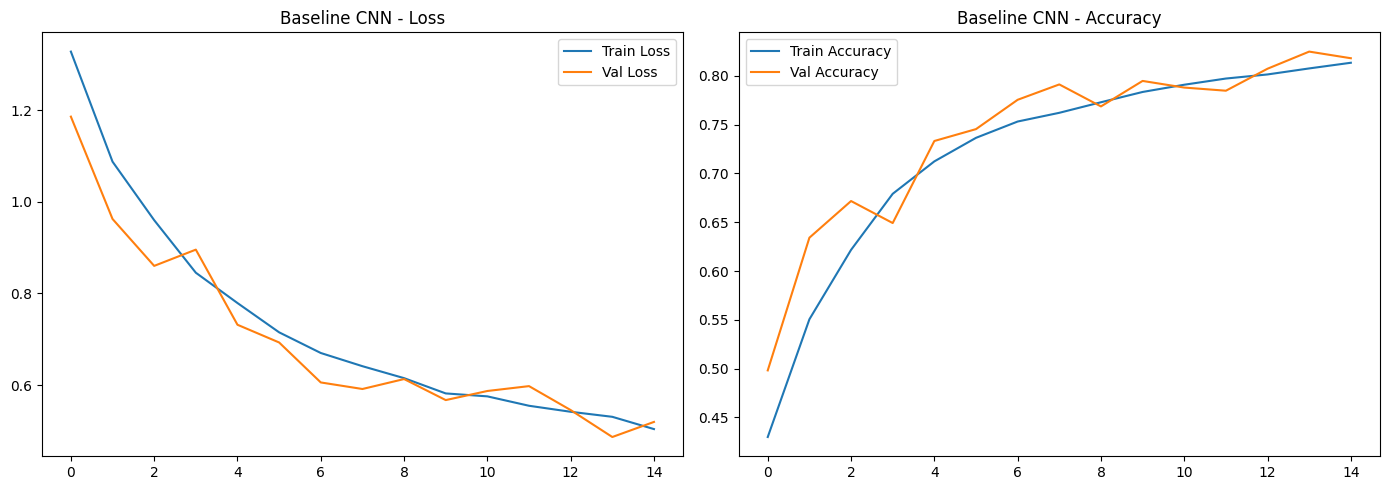


Baseline CNN
Test Loss: 0.4933
Test Accuracy: 0.8247

Classification Report:

              precision    recall  f1-score   support

   buildings       0.87      0.68      0.77       437
      forest       0.94      0.96      0.95       474
     glacier       0.84      0.74      0.79       553
    mountain       0.82      0.75      0.79       525
         sea       0.78      0.87      0.83       510
      street       0.74      0.94      0.83       501

    accuracy                           0.82      3000
   macro avg       0.83      0.82      0.82      3000
weighted avg       0.83      0.82      0.82      3000



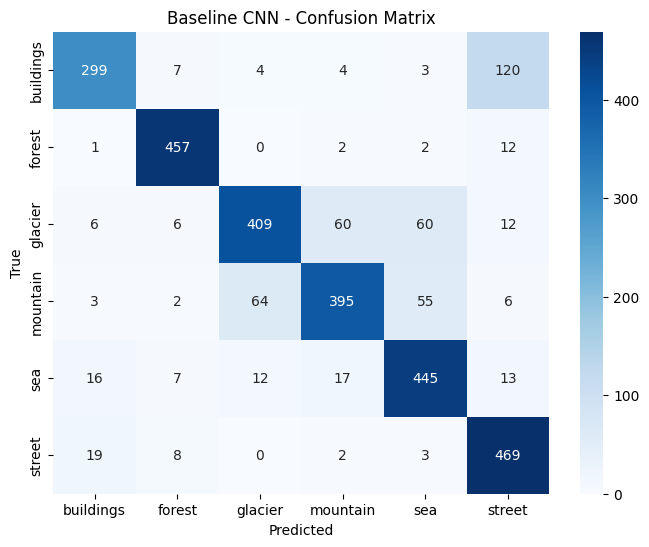

In [41]:
plot_history(history_baseline, "Baseline CNN")

baseline_acc = evaluate_model(
    baseline_model,
    test_gen,
    "Baseline CNN"
)

In [42]:
def build_deeper():

    model = Sequential([

        keras.Input(shape=(128,128,3)),

        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),

        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),
        Dropout(0.25),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),
        Dropout(0.25),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),

        MaxPooling2D(2,2),
        Dropout(0.3),

        GlobalAveragePooling2D(),

        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(256, activation='relu'),

        Dense(NUM_CLASSES, activation='softmax')

    ])

    return model

In [43]:
deeper_model = build_deeper()

deeper_model.summary()

deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 850,598 (3.24 MB)

 Trainable params: 848,614 (3.24 MB)

 Non-trainable params: 1,984 (7.75 KB)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7437 - loss: 0.6913

100/100 ━━━━━━━━━━━━━━━━━━━━ 488s 5s/step - accuracy: 0.7334 - loss: 0.7268 - val_accuracy: 0.7359 - val_loss: 0.6849
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 483s 5s/step - accuracy: 0.7600 - loss: 0.6644 - val_accuracy: 0.6484 - val_loss: 0.9152
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 542s 5s/step - accuracy: 0.7669 - loss: 0.6500 - val_accuracy: 0.4344 - val_loss: 2.1634
Epoch 4/10
 50/100 ━━━━━━━━━━━━━━━━━━━━ 3:48 5s/step - accuracy: 0.7398 - loss: 0.7212

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 263s 3s/step - accuracy: 0.7456 - loss: 0.6821 - val_accuracy: 0.7656 - val_loss: 0.5618
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7776 - loss: 0.6493

100/100 ━━━━━━━━━━━━━━━━━━━━ 564s 6s/step - accuracy: 0.7744 - loss: 0.6482 - val_accuracy: 0.8938 - val_loss: 0.2951
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 564s 6s/step - accuracy: 0.7763 - loss: 0.5986 - val_accuracy: 0.3797 - val_loss: 2.0833
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 618s 6s/step - accuracy: 0.7688 - loss: 0.6410 - val_accuracy: 0.7734 - val_loss: 0.6077
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 264s 3s/step - accuracy: 0.7900 - loss: 0.5532 - val_accuracy: 0.5312 - val_loss: 1.5857

Deeper Training Time: 63.35 minutes


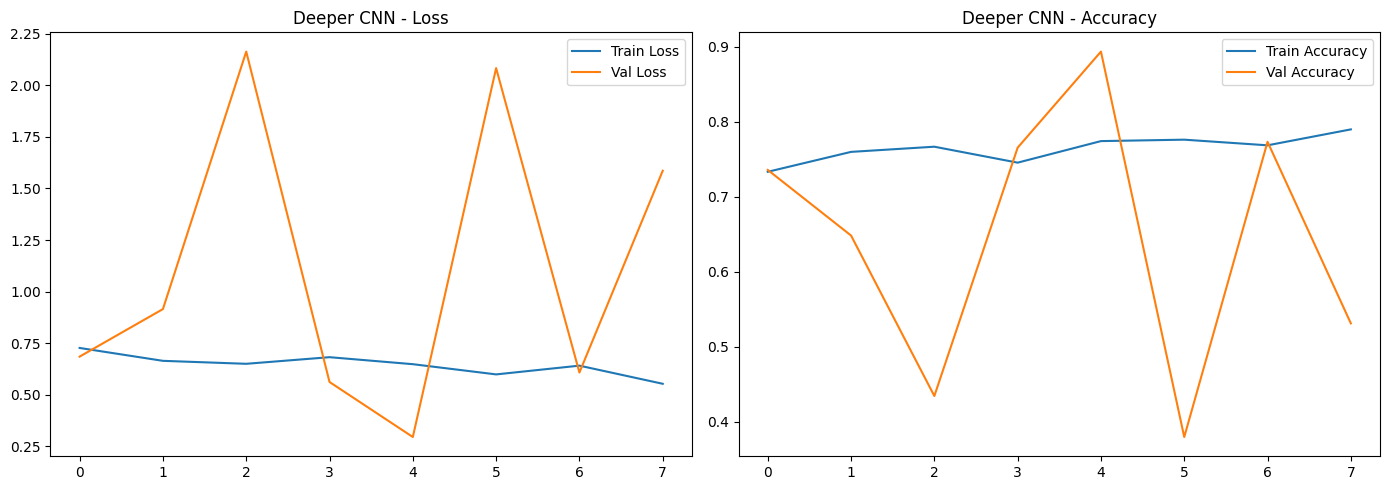


Deeper CNN
Test Loss: 0.7079
Test Accuracy: 0.7330

Classification Report:

              precision    recall  f1-score   support

   buildings       0.62      0.90      0.73       437
      forest       0.85      0.98      0.91       474
     glacier       0.91      0.35      0.50       553
    mountain       0.65      0.75      0.70       525
         sea       0.69      0.87      0.77       510
      street       0.85      0.63      0.72       501

    accuracy                           0.73      3000
   macro avg       0.76      0.74      0.72      3000
weighted avg       0.77      0.73      0.72      3000



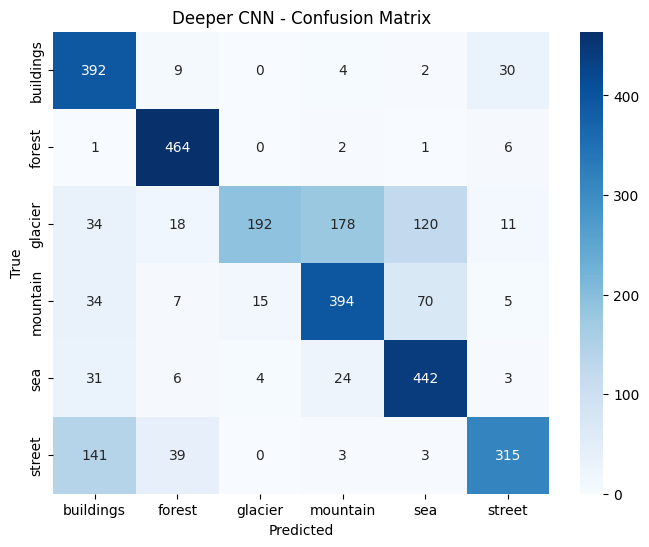

In [48]:
callbacks_deeper = [

    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        MODEL_SAVE + 'deeper_best.h5',
        save_best_only=True,
        monitor='val_accuracy'
    )
]

start = time.time()

history_deeper = deeper_model.fit(
    train_gen,
    validation_data=val_gen,

    epochs=10,
    steps_per_epoch=100,
    validation_steps=20,

    callbacks=callbacks_deeper
)

deeper_time = time.time() - start

print(f"\nDeeper Training Time: {deeper_time/60:.2f} minutes")

plot_history(history_deeper, 'Deeper CNN')

deeper_acc = evaluate_model(
    deeper_model,
    test_gen,
    'Deeper CNN'
)

In [49]:
print("="*60)

print(f"{'Model':<30} {'Accuracy':>10}")

print("="*60)

print(f"{'Baseline CNN':<30} {baseline_acc:>10.4f}")
print(f"{'Deeper CNN':<30} {deeper_acc:>10.4f}")

print("="*60)

Model                            Accuracy
Baseline CNN                       0.8247
Deeper CNN                         0.7330
